# YOLOv7 — PhenoBench multiclass fine-tuning

Fine-tunes a configurable **YOLOv7** architecture on PhenoBench multiclass
(`crop` / `weed`) plant detection. The main configuration independently selects
the model architecture (`MODEL`), source-data view (`TILED`), and training and
inference resolution (`IMG`), so copied notebooks need only change those knobs.

For context, **Weyler et al. 2024, Table 5** reports the following hidden-test
results for full YOLOv7:

| Approach | mAP | mAP₅₀ | mAP₇₅ | AP crop | AP weed |
|---|---|---|---|---|---|
| Faster R-CNN | 40.43 | 65.07 | 40.19 | 63.23 | 17.62 |
| Mask R-CNN | 38.68 | 63.72 | 38.07 | 60.32 | 17.05 |
| **YOLOv7** | **60.48** | **82.47** | **62.30** | **83.06** | **37.91** |

The mounted **`phenobench-yolo`** Kaggle dataset was produced by
`05_export_yolo_phenobench.ipynb` and provides both native full frames and an
overlapping tiled view. This notebook selects the matching dataset subdirectory
and builds only a writable symlink view for YOLOv7's cache files. The exporter
drops partial plants (`plant_visibility <= 0.5`) because YOLO labels cannot
encode do-not-care instances.

> **Caveat.** The paper numbers use the hidden PhenoBench test set. This
> notebook evaluates on the local labeled `val` split. Architecture, image
> sampling, and resolution may also differ according to the configuration, so
> the printed metrics are directly comparable to Table 5 only when the complete
> experimental setup matches.

## 1 · Environment

Target runtime: **Kaggle**, GPU enabled. **Select the Python 3.10 image**
("Pin to original environment"), *not* the latest. The choice is binary on
Kaggle — pinned 3.10 or latest 3.12 — and for YOLOv7 the older one is correct:
the 3.10 image ships **numpy <1.24** and **torch 1.x/2.0**, the stack YOLOv7
(WongKinYiu, 2022) was written against, so it runs as-is. The latest 3.12 image
brings **numpy 2.x**, which *removed* `np.int` / `np.float`; YOLOv7's source
still uses them, so it raises `AttributeError`s until you patch its files. This
is a pure-PyTorch run with **no TensorFlow**, so the project's `>=3.10,<3.11`
pin (which exists only for TF 2.12) is irrelevant here — 3.10 is chosen for
YOLOv7's sake, not the repo's. Torch / OpenCV come from the image; we add only
YOLOv7's extras, the `phenobench` dataloader, and this project (`--no-deps`, so
no TensorFlow stack).

In [1]:
!python -V
!nvidia-smi -L

Python 3.10.10
GPU 0: Tesla P100-PCIE-16GB (UUID: GPU-3a4eaeac-88af-7536-9ad5-42525630d768)


In [2]:
# YOLOv7 (official implementation).
!git clone --depth 1 https://github.com/WongKinYiu/yolov7.git

# YOLOv7 extras not always present on Kaggle, plus this project (only used here
# to regenerate data.yaml against the mounted dataset -> no TensorFlow, and no
# phenobench: materialization lives in the export notebook).
!pip install --no-cache-dir thop phenobench
!pip install --no-cache-dir --no-deps git+https://github.com/frdiener/agri-vision-edge.git

Cloning into 'yolov7'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 127 (delta 25), reused 123 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (127/127), 39.53 MiB | 31.35 MiB/s, done.
Resolving deltas: 100% (25/25), done.
  Cloning https://github.com/frdiener/agri-vision-edge.git to /tmp/pip-req-build-nyeqlan7
  Running command git clone --filter=blob:none --quiet https://github.com/frdiener/agri-vision-edge.git /tmp/pip-req-build-nyeqlan7
  Resolved https://github.com/frdiener/agri-vision-edge.git to commit 5aa7e888bedede612b47db1c8a7c39c2d7488b26
  Installing build dependencies ... - \ | / - done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
  Created wheel for agri-vision-edge: filename=agri_vision_edge-0.1.0-py3-none-any.whl size=1935025 sha256=98622031e3be4daa2b562a3e047091d1bfb188bde28df5b32e66483

## 2 · Configuration

`MODEL`, `TILED`, and `IMG` are independent experiment knobs. The derived model
and dataset variants are propagated into run naming, export provenance, and
artifact packaging; no downstream cell needs to be edited when they change.

In [3]:
from pathlib import Path

# ---------------------------------------------------------------------------
# Experiment configuration
# ---------------------------------------------------------------------------

IMG = 320           # training/inference resolution
TILED = True       # False: 1024² frames; True: overlapping ~512² tiles
MODEL = "tiny"     # "full" or "tiny" YOLOv7 architecture

EPOCHS = 100

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------

YOLO_DS_ROOT = Path(
    "/kaggle/input/datasets/freimutdiener/phenobench-yolo"
)

WORK = Path("/kaggle/working")
RUNS_DIR = WORK / "runs"

# ---------------------------------------------------------------------------
# Derived configuration
# ---------------------------------------------------------------------------

assert MODEL in {"full", "tiny"}

MODEL_STEM = "yolov7-tiny" if MODEL == "tiny" else "yolov7"

CFG_PRESET = {
    "dataset_subdir": "tiled512" if TILED else "full",
    "img": IMG,
    "cfg": f"cfg/training/{MODEL_STEM}.yaml",
    "weights": f"{MODEL_STEM}.pt",
    "hyp": (
        "data/hyp.scratch.tiny.yaml"
        if MODEL == "tiny"
        else "data/hyp.scratch.custom.yaml"
    ),
    "batch": 32 if MODEL == "tiny" else 16,
    "epochs": EPOCHS,
}

MODEL_VARIANT = MODEL
DATASET_VARIANT = CFG_PRESET["dataset_subdir"]
VARIANT = f"{MODEL_VARIANT}_{DATASET_VARIANT}_{IMG}"

DATASET_DIR = YOLO_DS_ROOT / DATASET_VARIANT
IMG = CFG_PRESET["img"]
CFG = CFG_PRESET["cfg"]
WEIGHTS = CFG_PRESET["weights"]
HYP = CFG_PRESET["hyp"]
BATCH = CFG_PRESET["batch"]
EPOCHS = CFG_PRESET["epochs"]

RUN_NAME = f"{MODEL_STEM}_phenobench_{DATASET_VARIANT}_{IMG}"

assert DATASET_DIR.exists(), (
    f"missing mount: {DATASET_DIR} -- attach the phenobench-yolo dataset"
)

print(
    f"variant={VARIANT}  model={MODEL_STEM}  img={IMG}  tiled={TILED}  "
    f"dataset={DATASET_DIR}  batch={BATCH}  cfg={CFG}"
)

variant=tiny_tiled512_320  model=yolov7-tiny  img=320  tiled=True  dataset=/kaggle/input/datasets/freimutdiener/phenobench-yolo/tiled512  batch=32  cfg=cfg/training/yolov7-tiny.yaml


## 3 · Point YOLOv7 at the dataset (writable view)

The images + labels are already materialized in the mount, but YOLOv7 writes a
`*.cache` file **next to the labels** — and `/kaggle/input` is read-only, so
training would crash with `… train.cache cannot be opened`.

So we build a thin **writable view** under the working dir: `images/` and
`labels/` are real directories whose `train` / `val` sub-dirs **symlink** back
to the mount (no copy — instant). The cache then lands in a writable directory.
`data.yaml` points at this view with **absolute** `train` / `val` paths (YOLOv7
ignores the ultralytics `path:` key and resolves these against its own cwd, so
they must be absolute).

In [4]:
import os
from agri_vision_edge.data import (
    PHENOBENCH_MULTICLASS,
    write_data_yaml,
    yolo_class_names,
)

DATASET_DEF = PHENOBENCH_MULTICLASS
class_names = yolo_class_names(DATASET_DEF)  # ["crop", "weed"]

# Writable view: real images/ + labels/ dirs, split sub-dirs symlinked to mount.
VIEW_DIR = WORK / "ds" / CFG_PRESET["dataset_subdir"]
for sub in ("images", "labels"):
    (VIEW_DIR / sub).mkdir(parents=True, exist_ok=True)
    for split in ("train", "val"):
        link = VIEW_DIR / sub / split
        if link.is_symlink() or link.exists():
            continue
        os.symlink(DATASET_DIR / sub / split, link)

DATA_YAML = write_data_yaml(
    VIEW_DIR, DATASET_DEF,
    train_split="train", val_split="val",
    dest=WORK / "data.yaml",
)
print("data.yaml:\n" + DATA_YAML.read_text())

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


data.yaml:
train: /kaggle/working/ds/tiled512/images/train
val: /kaggle/working/ds/tiled512/images/val
nc: 2
names: ['crop', 'weed']



### Sanity check — draw one sample with its boxes

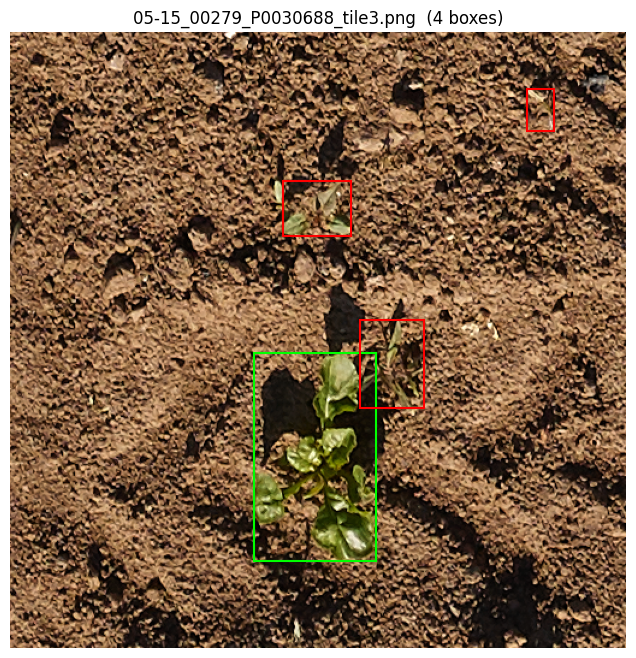

In [5]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

colors = {0: "lime", 1: "red"}

img_paths = sorted((DATASET_DIR / "images" / "train").glob("*.png"))
sample = random.choice(img_paths)
img = Image.open(sample)
W, H = img.size
label = (DATASET_DIR / "labels" / "train" / f"{sample.stem}.txt").read_text().splitlines()

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
for line in label:
    cls, cx, cy, w, h = line.split()
    cls = int(cls); cx, cy, w, h = map(float, (cx, cy, w, h))
    x0 = (cx - w / 2) * W; y0 = (cy - h / 2) * H
    ax.add_patch(patches.Rectangle((x0, y0), w * W, h * H,
                                   fill=False, edgecolor=colors.get(cls, "yellow"), lw=1.5))
ax.set_title(f"{sample.name}  ({len(label)} boxes)")
ax.axis("off")
plt.show()

## 4 · Train

The selected architecture starts from its matching COCO-pretrained checkpoint.
`nc` is taken from `data.yaml`, so the stock model config needs no editing. The
batch size is derived from `MODEL`; lower `BATCH` if the selected architecture
and image size exceed GPU memory.

`WANDB_MODE=disabled` stops YOLOv7's Weights & Biases logger from prompting for
a login (wandb is preinstalled on Kaggle); training still writes its own
`results.txt` and curves under the variant-specific `RUN_NAME`.

In [6]:
WEIGHTS_URL = f"https://github.com/WongKinYiu/yolov7/releases/download/v0.1/{WEIGHTS}"
!wget -nc {WEIGHTS_URL} -P yolov7/
!ls -lh yolov7/{WEIGHTS}

--2026-08-19 15:24:07--  https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7-tiny.pt
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/511187726/ba7d01ee-125a-4134-8864-fa1abcbf94d5?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-19T16%3A13%3A43Z&rscd=attachment%3B+filename%3Dyolov7-tiny.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-19T15%3A12%3A51Z&ske=2026-08-19T16%3A13%3A43Z&sks=b&skv=2018-11-09&sig=iEWIxjzlFtc6nrFZO9ewxkThr5csnV9LPGNJ7ngivkM%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NzE1NDg0OCwibmJmIjoxNzg3MTUzMDQ4LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNv

In [7]:
!cd yolov7 && WANDB_MODE=disabled python train.py \
  --workers 4 --device 0 \
  --batch-size {BATCH} \
  --data {DATA_YAML} \
  --img {IMG} {IMG} \
  --cfg {CFG} \
  --weights {WEIGHTS} \
  --hyp {HYP} \
  --epochs {EPOCHS} \
  --name {RUN_NAME} \
  --project {RUNS_DIR} \
  --exist-ok

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
train: Scanning '/kaggle/working/ds/tiled512/labels/train' images and labels... 
val: Scanning '/kaggle/working/ds/tiled512/labels/val' images and labels... 3088

autoanchor: Analyzing anchors... anchors/target = 5.07, Best Possible Recall (BPR) = 0.9994
      0/99     0.44G   0.07086   0.01262   0.01676    0.1002       193       320
               Class      Images      Labels           P           R      mAP@.5
 

## 5 · Evaluate on `val`

`test.py` reports per-class AP at the COCO IoU sweep (mAP) plus mAP₅₀ and
mAP₇₅. The paper result below is context only unless the selected architecture,
source-data view, resolution, and evaluation split all match its setup.

In [8]:
BEST = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
!cd yolov7 && WANDB_MODE=disabled python test.py \
  --data {DATA_YAML} \
  --img {IMG} \
  --batch {BATCH} \
  --conf 0.001 --iou 0.65 \
  --task val \
  --weights {BEST} \
  --name {RUN_NAME}_eval \
  --project {RUNS_DIR} \
  --exist-ok \
  --verbose

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Namespace(weights=['/kaggle/working/runs/yolov7-tiny_phenobench_tiled512_320/weights/best.pt'], data='/kaggle/working/data.yaml', batch_size=32, img_size=320, conf_thres=0.001, iou_thres=0.65, task='val', device='', single_cls=False, augment=False, verbose=True, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project='/kaggle/working/runs', name='yolov7-tiny_phenobench_tiled512_320_eval', exist_ok=True, no_trace=False, v5_metric=False)
Fusing layers... 
IDetect.fuse
/opt/conda/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/TensorShape.cpp:3483

Paper reference (hidden test set) for side-by-side reading:

```
YOLOv7   mAP 60.48   mAP50 82.47   mAP75 62.30   AP crop 83.06   AP weed 37.91
```

Our `val` numbers print above. Differences can result from the validation vs.
hidden-test split and from any configured change to the architecture, image
sampling, or network resolution.

## 6 · Package the variant artifact

Writes the trained weights, `data.yaml`, training curves, and a manifest under
`/kaggle/working/artifact/<RUN_NAME>/`. The model variant, dataset variant, and
input size are carried from the configuration, and only the matching dataset
export record is embedded. The mounted image tree is not republished.

In [9]:
import json
import shutil

ART = WORK / "artifact" / RUN_NAME
ART.mkdir(parents=True, exist_ok=True)

run_dir = RUNS_DIR / RUN_NAME
for fname in ["weights/best.pt", "results.txt", "results.png",
              "confusion_matrix.png", "PR_curve.png"]:
    src = run_dir / fname
    if src.exists():
        dst = ART / Path(fname).name
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy(src, dst)

shutil.copy(DATA_YAML, ART / "data.yaml")

manifest = {
    "task": "object_detection",
    "model": MODEL_STEM,
    "model_variant": MODEL_VARIANT,
    "dataset": "phenobench_multiclass",
    "dataset_variant": DATASET_VARIANT,
    "variant": VARIANT,
    "tiled": TILED,
    "classes": class_names,
    "img_size": IMG,
    "dataset_dir": str(DATASET_DIR),
    "epochs": EPOCHS,
    "batch": BATCH,
    "paper_baseline_testset": {
        "mAP": 60.48, "mAP50": 82.47, "mAP75": 62.30,
        "AP_crop": 83.06, "AP_weed": 37.91,
    },
}

# Carry over only the selected dataset variant's export provenance.
export_manifest = YOLO_DS_ROOT / "export_manifest.json"
if export_manifest.exists():
    exported = json.loads(export_manifest.read_text())
    exported_variants = exported.get("variants", {})
    assert DATASET_VARIANT in exported_variants, (
        f"{export_manifest} has no {DATASET_VARIANT!r} variant; "
        f"available: {sorted(exported_variants)}"
    )
    manifest["dataset_export"] = {
        "dataset": exported.get("dataset"),
        "variant": DATASET_VARIANT,
        **exported_variants[DATASET_VARIANT],
    }

(ART / "manifest.json").write_text(json.dumps(manifest, indent=2))

print("Artifact contents:")
for p in sorted(ART.rglob("*")):
    print(" ", p.relative_to(ART))

Artifact contents:
  PR_curve.png
  best.pt
  confusion_matrix.png
  data.yaml
  manifest.json
  results.png
  results.txt
